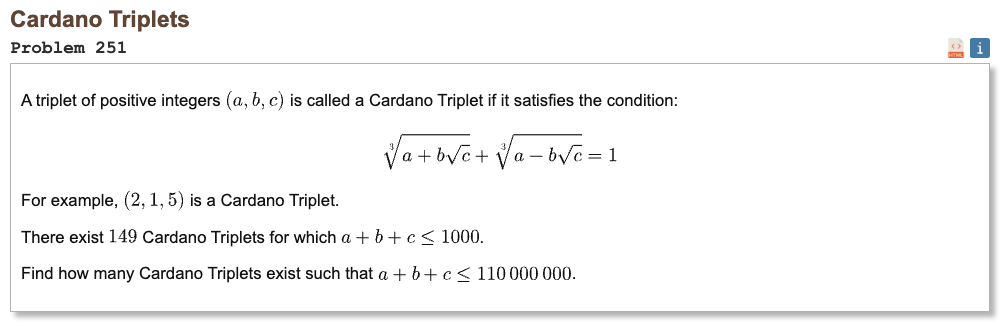

## Initial approach

* rewrite the cube root condition into a pure integer relation so you never touch floating point
* from that relation you can show a must be 2 mod 3, so write a as 3k+2 and reduce the condition to one product equality
* switch to u = k+1 so the formula becomes cleaner and u stays in a manageable range
* for each u, compute t = u^2(8u-3), then every valid pair (b,c) is exactly a factor choice with b^2 dividing t and c = t / b^2
* generate all possible b values by factoring t (easy because u ≤ about 110k and 8u-3 ≤ 880k)
* for each candidate b, compute c and check the limit a+b+c
* sum the count over all u and print

In [1]:
from math import isqrt

LIMIT = 110_000_000

def build_spf(n):
    spf = list(range(n + 1))
    spf[0] = 0
    if n >= 1:
        spf[1] = 1
    for i in range(2, isqrt(n) + 1):
        if spf[i] == i:
            step = i
            start = i * i
            for j in range(start, n + 1, step):
                if spf[j] == j:
                    spf[j] = i
    return spf

def factor_with_spf(x, spf):
    f = {}
    while x > 1:
        p = spf[x]
        e = 0
        while x % p == 0:
            x //= p
            e += 1
        f[p] = f.get(p, 0) + e
    return f

def count_for_u(u, spf_u, spf_n):
    a = 3 * u - 1
    if a >= LIMIT:
        return 0

    n = 8 * u - 3
    fu = factor_with_spf(u, spf_u)
    fn = factor_with_spf(n, spf_n)

    ft = {}
    for p, e in fu.items():
        ft[p] = ft.get(p, 0) + 2 * e
    for p, e in fn.items():
        ft[p] = ft.get(p, 0) + e

    primes = list(ft.items())
    t = u * u * n
    max_sum_rest = LIMIT - a

    bs = [1]
    for p, E in primes:
        m = E // 2
        cur = []
        pe = 1
        for _ in range(m + 1):
            for b in bs:
                cur.append(b * pe)
            pe *= p
        bs = cur

    cnt = 0
    for b in bs:
        bb = b * b
        c = t // bb
        if b + c <= max_sum_rest:
            cnt += 1
    return cnt

def solve():
    umax = int((LIMIT / (8 ** 0.5)) ** (2 / 3)) + 10
    nmax = 8 * umax + 5

    spf_u = build_spf(umax)
    spf_n = build_spf(nmax)

    total = 0
    for u in range(1, umax + 1):
        total += count_for_u(u, spf_u, spf_n)

    print("Result:", total)

solve()

Result: 510059
